# Exploratory Data Analysis on the 3D Printer Task Tracing Dataset
## UGR 4971 - ML Informed RTOS Schedulers

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/printer_tasks.csv")

In [3]:
df["run_ratio"] = df["running_time"] / df["timestamp"]
df.loc[df["idle_time"] != 0, "run_ratio"] = (df["running_time"] / df["idle_time"]) / df["timestamp"]

df.head()

,process,name,timestamp,running_time,idle_time,uart_transmit_calls,uart_receive_calls,i2c_read_calls,i2d_write_calls,spi_transfer_calls,gpio_interrupt_calls,adc_read_calls,sleep_calls,run_ratio
0,0,network,1002,1002,0,259,260,0,0,518,0,0,66563.0,1.000000
1,0,gcode_parser,1502,1418,84,160,160,0,0,0,0,0,160.0,0.011239
2,1,stepper,1502,90,1412,0,0,0,0,17,17,0,17.0,0.000042
3,2,status_led,1502,0,1502,0,0,0,0,0,2,0,1.0,0.000000
4,0,status_led,2002,14,1988,0,0,0,0,0,1,0,1.0,0.000004


In [4]:
df["name"] = df["name"].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   process               2542 non-null   int64   
 1   name                  2542 non-null   category
 2   timestamp             2542 non-null   int64   
 3   running_time          2542 non-null   int64   
 4   idle_time             2542 non-null   int64   
 5   uart_transmit_calls   2542 non-null   int64   
 6   uart_receive_calls    2542 non-null   int64   
 7   i2c_read_calls        2542 non-null   int64   
 8   i2d_write_calls       2542 non-null   int64   
 9   spi_transfer_calls    2542 non-null   int64   
 10  gpio_interrupt_calls  2542 non-null   int64   
 11  adc_read_calls        2542 non-null   int64   
 12  sleep_calls           2542 non-null   float64 
 13  run_ratio             2542 non-null   float64 
dtypes: category(1), float64(2), int64(11)
memory usage: 261.

In [5]:
df["name"].unique()
color_mapping = {"network": "red", "gcode_parser": "blue", "stepper": "green", "status_led": "yellow", "temp_monitor": "pink", "power": "orange", "safety": "purple"}

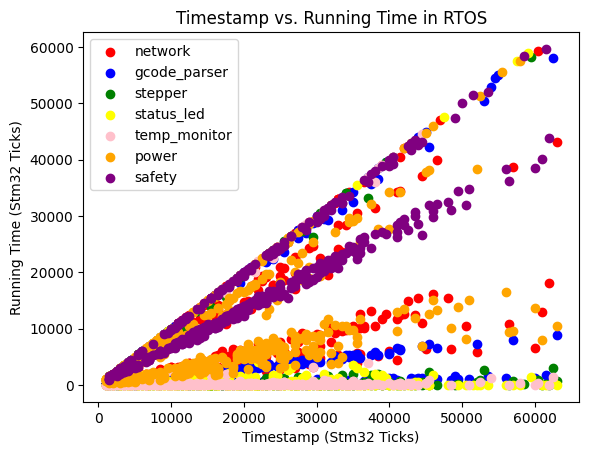

In [6]:

for cat, color in color_mapping.items():
    subset = df[df["name"] == cat]
    plt.scatter("timestamp", "running_time", data=subset, c=color, label=cat)

plt.xlabel("Timestamp (Stm32 Ticks)")
plt.ylabel("Running Time (Stm32 Ticks)")
plt.title("Timestamp vs. Running Time in RTOS")

plt.legend()

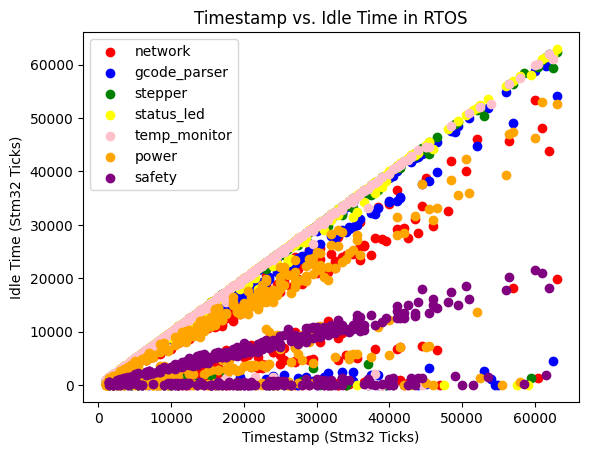

In [7]:

for cat, color in color_mapping.items():
    subset = df[df["name"] == cat]
    plt.scatter("timestamp", "idle_time", data=subset, c=color, label=cat)

plt.xlabel("Timestamp (Stm32 Ticks)")
plt.ylabel("Idle Time (Stm32 Ticks)")
plt.title("Timestamp vs. Idle Time in RTOS")

plt.legend()

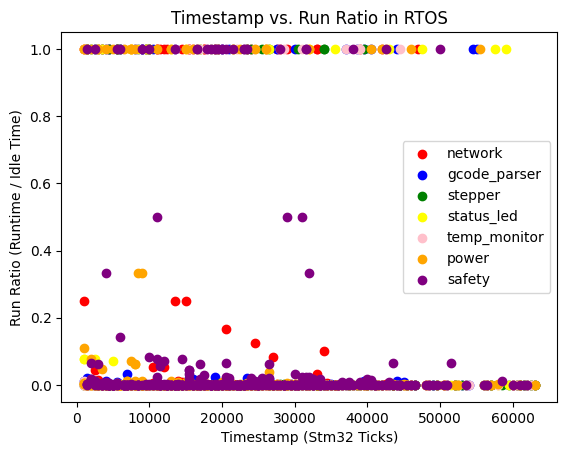

In [8]:
for cat, color in color_mapping.items():
    subset = df[df["name"] == cat]
    plt.scatter("timestamp", "run_ratio", data=subset, c=color, label=cat)

plt.xlabel("Timestamp (Stm32 Ticks)")
plt.ylabel("Run Ratio (Runtime / Idle Time)")
plt.title("Timestamp vs. Run Ratio in RTOS")

plt.legend()

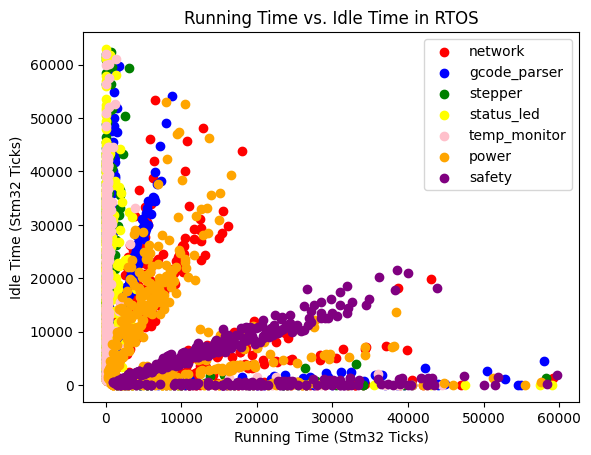

In [9]:
for cat, color in color_mapping.items():
    subset = df[df["name"] == cat]
    plt.scatter("running_time", "idle_time", data=subset, c=color, label=cat)

plt.xlabel("Running Time (Stm32 Ticks)")
plt.ylabel("Idle Time (Stm32 Ticks)")
plt.title("Running Time vs. Idle Time in RTOS")

plt.legend()